# Review 2. Smoothing and LOWESS, on one spectrum

The preprocessing parameters that review notebook 1 and 3 scan, shown on a single
spectrum.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0 |
| `spectrum/<filename_csv>` | the raw spectrum drawn here |

| output | what it shows |
| --- | --- |
| `figure/review/gaussian_smoothing_comparison.pdf` / `.png` | Gaussian smoothing at sigma = 10, 20, 30, 40, 50 A |
| `figure/review/lowess_continuum_comparison.pdf` / `.png` | the LOWESS continuum at several `frac` |


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from statsmodels.nonparametric.smoothers_lowess import lowess

import astropy.units as u
from specutils import Spectrum1D
from specutils.manipulation import gaussian_smooth

u_f_AA = u.erg/u.cm/u.cm/u.s/u.AA

# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_DIR = './spectrum'

FIGURE_DIR = './figure/review'
os.makedirs(FIGURE_DIR, exist_ok=True)

In [2]:
data_list = pd.read_csv(PARAMS_PATH)


In [3]:
plt.rcParams['figure.figsize'] = (10.0, 4.5)
plt.rcParams['figure.dpi'] = 300

plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = 'True'
plt.rcParams['xtick.top'] = 'True'
plt.rcParams["xtick.minor.visible"] = 'True'
plt.rcParams["ytick.minor.visible"] = 'True'

plt.rcParams["xtick.major.width"] = 1
plt.rcParams["ytick.major.width"] = 1
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.minor.width"] = 0.5
plt.rcParams["xtick.major.size"] = 7
plt.rcParams["ytick.major.size"] = 7
plt.rcParams["xtick.minor.size"] = 4
plt.rcParams["ytick.minor.size"] = 4

In [4]:
# Settings, and the raw spectrum read through the notebook 1 pipeline:
# raw -> rest frame -> Del_Lambda interpolation -> median norm
#     -> LOWESS (frac=0.3) division -> Gaussian smooth -> common grid

TARGET_FILENAME_CSV = '2008Q_2008-02-09_02-09-36_FLWO-1.5m_FAST_CfA-Ia.csv'
RAW_FILE_PLOT   = os.path.join(SPECTRUM_DIR, TARGET_FILENAME_CSV)
SIGMA_LIST      = [10, 20, 30, 40, 50]       # Gaussian sigma [A]
FRAC_LIST_PLOT  = [0.2, 0.3, 0.5, 0.7]       # LOWESS frac
FRAC_FIXED      = 0.3                        # LOWESS frac held fixed in Figure 1

# z and Del_Lambda of this spectrum
row_plot        = data_list[data_list['filename_csv'] == TARGET_FILENAME_CSV].iloc[0]
z_plot          = row_plot['redshift']
DelLam_plot     = row_plot['Del_Lambda']
sn_plot         = row_plot['SN_name']

# (1)(2) read the raw spectrum and move it to the rest frame
rd = pd.read_csv(RAW_FILE_PLOT, header=None)
rd.drop_duplicates(subset=0, inplace=True)
AA_rest_plot   = (rd[0] / (1 + z_plot)).values
flux_rest_plot = (rd[1] * (1 + z_plot)).values

# (3) interpolate onto an even grid of Del_Lambda (the native resolution)
AA_nat   = np.arange(AA_rest_plot.min(), AA_rest_plot.max(), DelLam_plot)
f_nat    = interp1d(AA_rest_plot, flux_rest_plot, kind='cubic', fill_value='extrapolate')
flux_nat = f_nat(AA_nat)

# (4) median normalization
norm_nat = flux_nat / np.median(flux_nat)

# common output grid
AA_com = np.linspace(5000, 7000, 1000)

print(f"SN: {sn_plot},  z={z_plot:.5f},  Del_Lambda={DelLam_plot:.4f} Å/pix")
print(f"Native grid: {len(AA_nat)} points,  {AA_nat[0]:.1f}–{AA_nat[-1]:.1f} Å")

SN: SN2008Q,  z=0.00810,  Del_Lambda=1.4576 Å/pix
Native grid: 2683 points,  3447.1–7356.5 Å


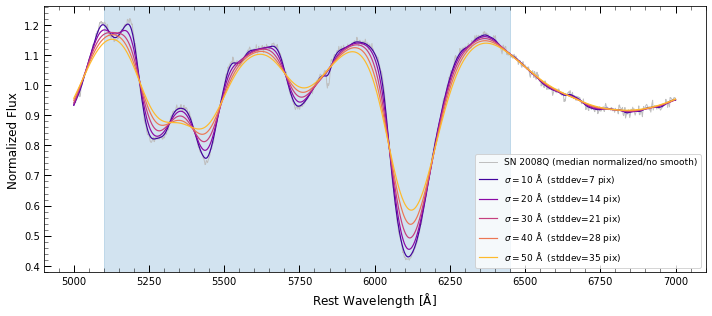

In [7]:
# Figure 1: Gaussian smoothing.  Continuum-normalize with LOWESS (frac=FRAC_FIXED),
# then smooth at each sigma and interpolate onto the common grid.

# continuum normalization, frac held at FRAC_FIXED
cont_fig1 = lowess(norm_nat, AA_nat, frac=FRAC_FIXED)[:, 1]
div_fig1  = norm_nat / cont_fig1
div_fig1[~np.isfinite(div_fig1)] = 0
sp_div    = Spectrum1D(flux=div_fig1 << u_f_AA, spectral_axis=AA_nat << u.AA)

# sigma = 0 (normalization only) as the baseline
f_base = interp1d(AA_nat, div_fig1, kind='cubic', fill_value='extrapolate')
base   = f_base(AA_com)

fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(AA_com, base, color='0.75', lw=1, label=f'SN 2008Q (median normalized/no smooth)')

colors = plt.cm.plasma(np.linspace(0.1, 0.85, len(SIGMA_LIST)))
for sigma, color in zip(SIGMA_LIST, colors):
    stddev_pix = int(sigma / DelLam_plot + 1)
    sm         = gaussian_smooth(sp_div, stddev=stddev_pix)
    f_out      = interp1d(sm.spectral_axis.value, sm.flux.value,
                          kind='cubic', fill_value='extrapolate')
    ax.plot(AA_com, f_out(AA_com), color=color, lw=1.2,
            label=rf'$\sigma={sigma}$ Å  (stddev={stddev_pix} pix)')

ax.axvspan(5100, 6450, color='tab:blue', alpha=0.2)

ax.set_xlabel(r'Rest Wavelength [${\rm \AA}$]', fontsize=12)
ax.set_ylabel(r'Normalized Flux',               fontsize=12)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/gaussian_smoothing_comparison.pdf', bbox_inches='tight', pad_inches=0.05)
fig.savefig(f'{FIGURE_DIR}/gaussian_smoothing_comparison.png', bbox_inches='tight', pad_inches=0.05)
plt.show()

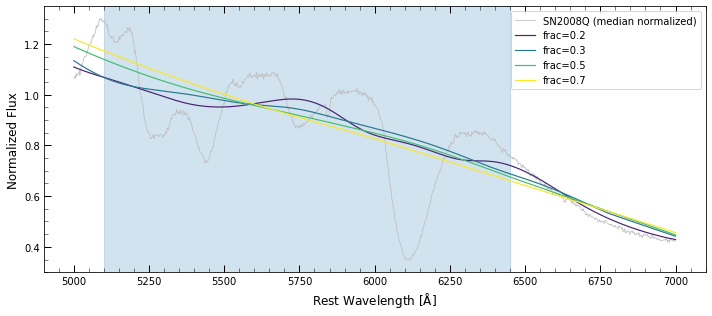

In [8]:
# Figure 2: LOWESS continuum.  The quasi-continuum drawn at each frac,
# on the median-normalized spectrum.

fig, ax = plt.subplots(figsize=(10,4.5))

# the median-normalized spectrum, on the common grid
f_norm = interp1d(AA_nat, norm_nat, kind='cubic', fill_value='extrapolate')
ax.plot(AA_com, f_norm(AA_com), color='0.75', lw=0.8, label='SN2008Q (median normalized)')

colors = plt.cm.viridis(np.linspace(0.1, 1, len(FRAC_LIST_PLOT)))
for frac, color in zip(FRAC_LIST_PLOT, colors):
    vals      = lowess(norm_nat, AA_nat, frac=frac)
    continuum = vals[:, 1]
    f_cont    = interp1d(AA_nat, continuum, kind='cubic', fill_value='extrapolate')
    ax.plot(AA_com, f_cont(AA_com), color=color, lw=1.2, label=f'frac={frac}')

ax.axvspan(5100, 6450, color='tab:blue', alpha=0.2)
ax.set_xlabel(r'Rest Wavelength [${\rm \AA}$]', fontsize=12)
ax.set_ylabel(r'Normalized Flux',               fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/lowess_continuum_comparison.pdf', bbox_inches='tight', pad_inches=0.05)
fig.savefig(f'{FIGURE_DIR}/lowess_continuum_comparison.png', bbox_inches='tight', pad_inches=0.05)
plt.show()